In [1]:
import datetime
import json
import os
import yaml

from glob import glob
from pprint import pprint


# read configuration file
import mejiro
config_file = os.path.join(os.path.dirname(mejiro.__file__), 'data', 'mejiro_config', 'roman_data_challenge_rung_1_unlabeled.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

if config['dev']:
    config['pipeline_label'] += '_dev'

In [2]:
with open(os.path.join(config['data_dir'], config['pipeline_label'], 'execution_times.json'), 'r') as f:
    execution_times = json.load(f)

pprint(execution_times)

{'01a': '0:04:20',
 '01b': '1 day, 20:17:03',
 '02': '6:15:27',
 '03': '1:58:47',
 '04': '1 day, 15:06:00',
 '05': '0:00:27',
 'snr': '2:00:18'}


In [3]:
total_time = 0
for script_name, times in execution_times.items():
    h, m, s = times.split(':')
    if 'days' in h:
        d, h = h.split('days, ')
        h = int(d) * 24 + int(h)
    elif 'day' in h:
        d, h = h.split('day, ')
        h = int(d) * 24 + int(h)
    time = (int(h) * 3600) + (int(m) * 60) + int(s)
    total_time += time

print(
    f'Total pipeline execution time: {datetime.timedelta(seconds=total_time)}, {total_time} seconds, {total_time / 3600:.2f} hours')

Total pipeline execution time: 3 days, 21:42:22, 337342 seconds, 93.71 hours


In [4]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '02')

pickles = sorted(glob(os.path.join(data_dir, 'sca*', f'lens_*.pkl')))
print(f'Found {len(pickles)} pickles in {data_dir}')

if len(pickles) > 0:
    print(f'Execution time per system: {total_time / len(pickles):.3f} seconds')
else:
    raise ValueError(f'No pickled exposures found in {data_dir}')

Found 87368 pickles in /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled/02
Execution time per system: 3.861 seconds


In [ ]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '05_romanisim')

band = config['synthetic_image']['bands'][0]
# pickles = sorted(glob(os.path.join(data_dir, 'sca*', f'Exposure_*_{band}.pkl')))
# pickles = sorted(glob(os.path.join(data_dir, 'Exposure_*.pkl')))

if len(pickles) > 0:
    print(f'Execution time per system: {total_time / len(pickles):.3f} seconds')
else:
    raise ValueError(f'No pickled exposures found in {data_dir}')

ValueError: No pickled exposures found in /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled/05_romanisim

{'02': 0, '03': 129, '04': 0, '05_romanisim': 0, '06': 0, 'snr': 0}


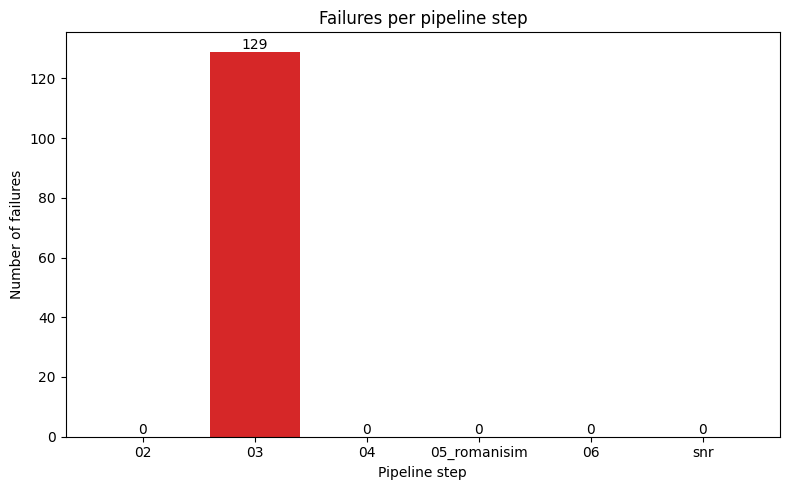

In [7]:
import matplotlib.pyplot as plt

pipeline_dir = os.path.join(config['data_dir'], config['pipeline_label'])
step_dirs = sorted(
    d for d in os.listdir(pipeline_dir)
    if os.path.isdir(os.path.join(pipeline_dir, d)) and d >= '02'
)

failure_counts = {}
for step in step_dirs:
    failure_counts[step] = len(glob(os.path.join(pipeline_dir, step, '**', 'failed_*'), recursive=True))

print(failure_counts)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(failure_counts.keys()), list(failure_counts.values()), color='C3')
ax.set_xlabel('Pipeline step')
ax.set_ylabel('Number of failures')
ax.set_title('Failures per pipeline step')
for bar, count in zip(bars, failure_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
            ha='center', va='bottom')
plt.tight_layout()
plt.show()